## Мой спотик

In [25]:
# Перед запуском убедитесь, что установлены библиотеки:
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn scipy joblib

In [26]:
# 1. ИМПОРТ БИБЛИОТЕК
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [27]:
# 2. ЗАГРУЗКА И ОЧИСТКА ДАННЫХ
def load_and_clean_data(filepath='Spotify.csv'):
    df = pd.read_csv(filepath)
    
    # Удаление пустой первой колонки
    if df.columns[0] == '' or 'Unnamed' in str(df.columns[0]):
        df = df.iloc[:, 1:].reset_index(drop=True)
        
    df = df.rename(columns={
        'artists': 'artist', 'album_name': 'album', 
        'track_name': 'track', 'track_genre': 'genre'
    })
    
    numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 
                    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
                    'liveness', 'valence', 'tempo', 'time_signature']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    if 'explicit' in df.columns:
        df['explicit'] = df['explicit'].astype(str).map(
            {'True': True, 'False': False, 'true': True, 'false': False, '1': True, '0': False}
        )
    
    # Имputation пропусков медианой по жанру
    if 'genre' in df.columns:
        df['genre'] = df['genre'].fillna(df['genre'].mode()[0])
        for col in numeric_cols:
            if col in df.columns:
                df[col] = df.groupby('genre')[col].transform(lambda x: x.fillna(x.median()))
                
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    df = df.dropna(subset=['popularity']).reset_index(drop=True)
    
    return df, numeric_cols

df, numeric_cols = load_and_clean_data('Spotify.csv')
print(f"Загружено: {df.shape[0]} строк, {df.shape[1]} колонок")

Загружено: 114000 строк, 20 колонок


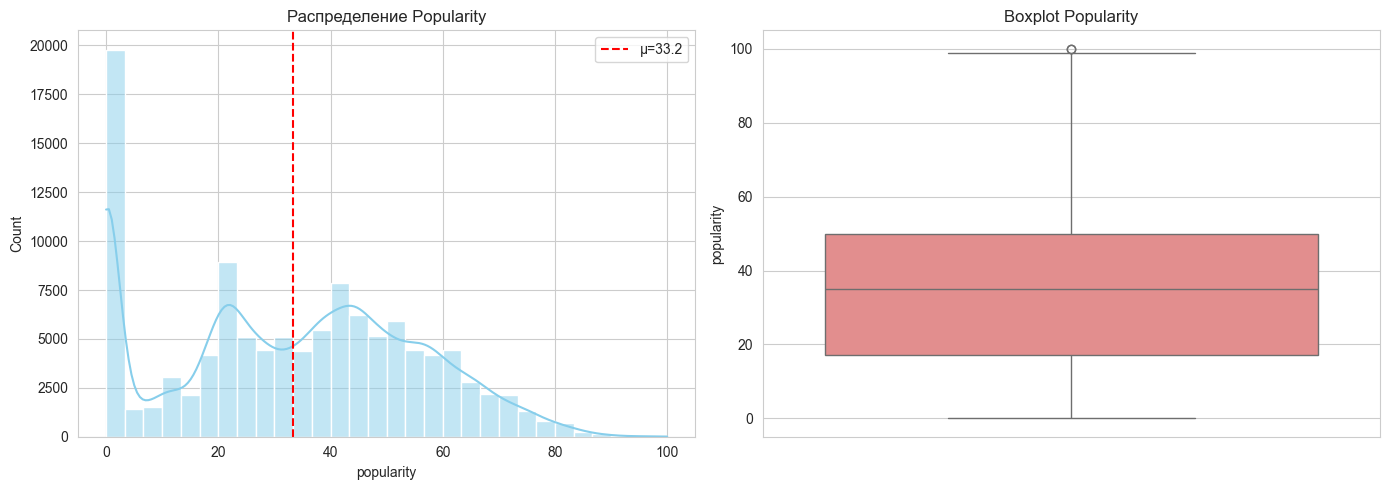

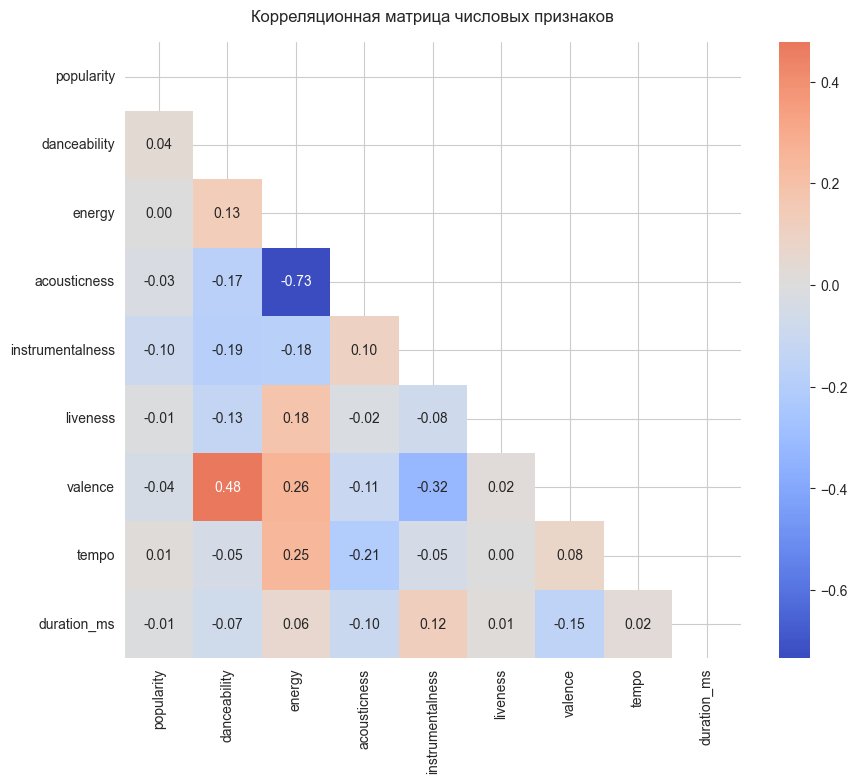

In [28]:
# 3. EDA: ТАРГЕТ И КОРРЕЛЯЦИЯ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['popularity'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(df['popularity'].mean(), color='red', ls='--', label=f'μ={df["popularity"].mean():.1f}')
axes[0].set_title('Распределение Popularity')
axes[0].legend()

sns.boxplot(y=df['popularity'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot Popularity')
plt.tight_layout()
plt.show()

features_for_corr = ['popularity', 'danceability', 'energy', 'acousticness', 
                     'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
corr_matrix = df[features_for_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица числовых признаков', pad=15)
plt.show()


ЭТАП 1: ФОРМУЛИРОВКА ГИПОТЕЗ НА ВСЕМ ДАТАСЕТЕ

1) Треки с высокой danceability популярнее


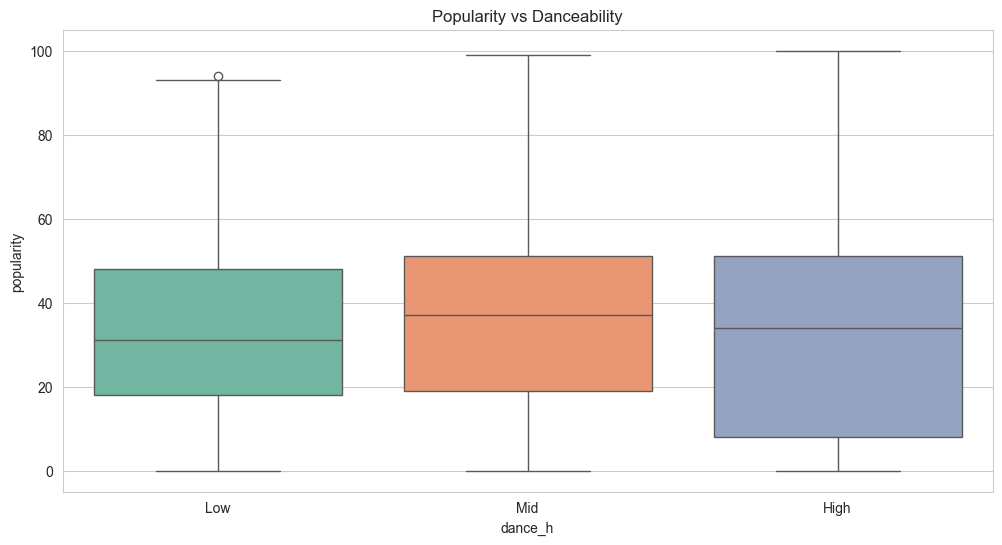

   => Средняя популярность High: 32.60

2) Акустические треки (acousticness > 0.8) менее популярны
   => Корреляция acousticness & popularity: -0.025
   => Средняя популярность acoustic>0.8: 29.11

3) Энергичные треки (energy > 0.7) с темпом 100-130 BPM популярнее
   => Корреляция combo_score & popularity: 0.002


In [29]:
# 4. EDA: ГИПОТЕЗЫ (ИССЛЕДОВАТЕЛЬСКИЙ ЭТАП)
print("\nЭТАП 1: ФОРМУЛИРОВКА ГИПОТЕЗ НА ВСЕМ ДАТАСЕТЕ\n")

# Гипотеза 1
print("1) Треки с высокой danceability популярнее")
df['dance_h'] = pd.cut(df['danceability'], bins=[0, 0.5, 0.7, 1], labels=['Low','Mid','High'])
sns.boxplot(data=df, x='dance_h', y='popularity', palette='Set2')
plt.title('Popularity vs Danceability')
plt.show()
print(f"   => Средняя популярность High: {df[df['dance_h']=='High']['popularity'].mean():.2f}")

# Гипотеза 2
print("\n2) Акустические треки (acousticness > 0.8) менее популярны")
print(f"   => Корреляция acousticness & popularity: {df['acousticness'].corr(df['popularity']):.3f}")
print(f"   => Средняя популярность acoustic>0.8: {df[df['acousticness']>0.8]['popularity'].mean():.2f}")

# Гипотеза 3
print("\n3) Энергичные треки (energy > 0.7) с темпом 100-130 BPM популярнее")
df['combo_score'] = df['energy'] * (1 - abs(df['tempo'] - 115)/115)
print(f"   => Корреляция combo_score & popularity: {df['combo_score'].corr(df['popularity']):.3f}")

In [30]:
# 5. FEATURE ENGINEERING & ПОДГОТОВКА X/Y

print("\nFEATURE ENGINEERING")
df['log_popularity'] = np.log1p(df['popularity'])
df['dance_energy_ratio'] = df['danceability'] / (df['energy'] + 1e-5)
df['valence_liveness_ratio'] = df['valence'] / (df['liveness'] + 1e-5)

df['duration_group'] = pd.cut(df['duration_ms'], bins=[0, 180000, 240000, np.inf], labels=['short', 'medium', 'long'])
df['loudness_group'] = pd.cut(df['loudness'], bins=[-np.inf, -15, -10, -5, np.inf], labels=['v_quiet', 'quiet', 'mod', 'loud'])
df['tempo_group'] = pd.cut(df['tempo'], bins=[0, 100, 130, np.inf], labels=['slow', 'medium', 'fast'])

df['is_acoustic'] = (df['acousticness'] > 0.8).astype(int)
df['is_dance'] = (df['danceability'] > 0.8).astype(int)

# Удаляем метаданные и временные колонки EDA
drop_cols = ['track_id', 'artist', 'album', 'track', 'popularity', 'log_popularity', 
             'dance_h', 'combo_score', 'duration_ms']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

y_log = df['log_popularity'].copy()
y_orig = df['popularity'].copy()

print(f"Признаки готовы. Финальный набор: {df_model.shape[1]} колонок")


FEATURE ENGINEERING
Признаки готовы. Финальный набор: 21 колонок


In [36]:
# 6. РАЗДЕЛЕНИЕ 80/10/10 + ГИПОТЕЗЫ НА ВАЛИДАЦИИ

# 1. Жёстко кодируем ВСЕ строковые/категориальные колонки в 0/1
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True, dtype=int)
    print(f"Закодировано категорий: {list(cat_cols)}")

X = df_model.copy()
y_log = df.loc[X.index, 'log_popularity'].copy() # Берём таргет строго по индексам X

# 2. Разделение 80/10/10
idx_all = X.index
idx_train, idx_temp = train_test_split(idx_all, test_size=0.2, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42) # 0.5 от 20% = 10%

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train_log, y_val_log, y_test_log = y_log[idx_train], y_log[idx_val], y_log[idx_test]

print(f"Данные оцифрованы и разделены:")
print(f"   Train: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"   Val:   {X_val.shape[0]}")
print(f"   Test:  {X_test.shape[0]}")
print(f"   Типы данных в X: {X_train.dtypes.value_counts()}") # Должно быть только int64/float64


print("\nПРОВЕРКА ГИПОТЕЗ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
val_data = df.loc[idx_val]

# H1
r1, p1 = stats.pearsonr(val_data['danceability'], val_data['popularity'])
print(f"1) Danceability vs Popularity: r={r1:.3f}, p={p1:.4e} {'+' if p1<0.05 and r1>0 else '-'}")

# H2
r2, p2 = stats.pearsonr(val_data['acousticness'], val_data['popularity'])
print(f"2) Acousticness vs Popularity: r={r2:.3f}, p={p2:.4e} {'+' if p2<0.05 and r2<0 else '-'}")

# H3
val_data['combo'] = val_data['energy'] * (1 - abs(val_data['tempo'] - 115)/115)
r3, p3 = stats.pearsonr(val_data['combo'], val_data['popularity'])
print(f"3) Energy*Tempo vs Popularity: r={r3:.3f}, p={p3:.4e} {'+' if p3<0.05 and r3>0 else '-'}")

Данные оцифрованы и разделены:
   Train: 91200 строк, 137 признаков
   Val:   11400
   Test:  11400
   Типы данных в X: int64      125
float64     11
bool         1
Name: count, dtype: int64

ПРОВЕРКА ГИПОТЕЗ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ
1) Danceability vs Popularity: r=0.037, p=6.8990e-05 +
2) Acousticness vs Popularity: r=-0.017, p=7.2084e-02 -
3) Energy*Tempo vs Popularity: r=-0.005, p=6.2437e-01 -


In [37]:
# 7. ОБУЧЕНИЕ МОДЕЛЕЙ
def calc_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train_log)
    results[name] = {
        'model': mdl,
        'train': calc_metrics(y_train_log, mdl.predict(X_train)),
        'val': calc_metrics(y_val_log, mdl.predict(X_val)),
        'test': calc_metrics(y_test_log, mdl.predict(X_test))
    }
    print(f"   {name}: Val R²={results[name]['val']['R2']:.4f}")

# Таблица метрик
metrics_data = []
for name, res in results.items():
    row = {'Model': name}
    for split, metrics_dict in res.items():
        if split == 'model':
            continue  # Пропускаем объект модели, чтобы не вызывать TypeError
        for metric, val in metrics_dict.items():
            row[f'{split}_{metric}'] = f"{val:.4f}"
    metrics_data.append(row)
    
metrics_df = pd.DataFrame(metrics_data)
print("\nСравнение метрик (на логарифмированном таргете):")
print(metrics_df.to_string(index=False))

   LinearRegression: Val R²=0.2880
   RandomForest: Val R²=0.1899
   XGBoost: Val R²=0.4148

Сравнение метрик (на логарифмированном таргете):
           Model train_RMSE train_MAE train_R2 val_RMSE val_MAE val_R2 test_RMSE test_MAE test_R2
LinearRegression     1.1846    0.7975   0.2771   1.1733  0.7921 0.2880    1.1860   0.8000  0.2820
    RandomForest     1.2378    0.8896   0.2107   1.2516  0.9028 0.1899    1.2502   0.8991  0.2023
         XGBoost     0.9202    0.6179   0.5638   1.0637  0.7118 0.4148    1.0729   0.7174  0.4125



Лучшая модель по Val R²: XGBoost


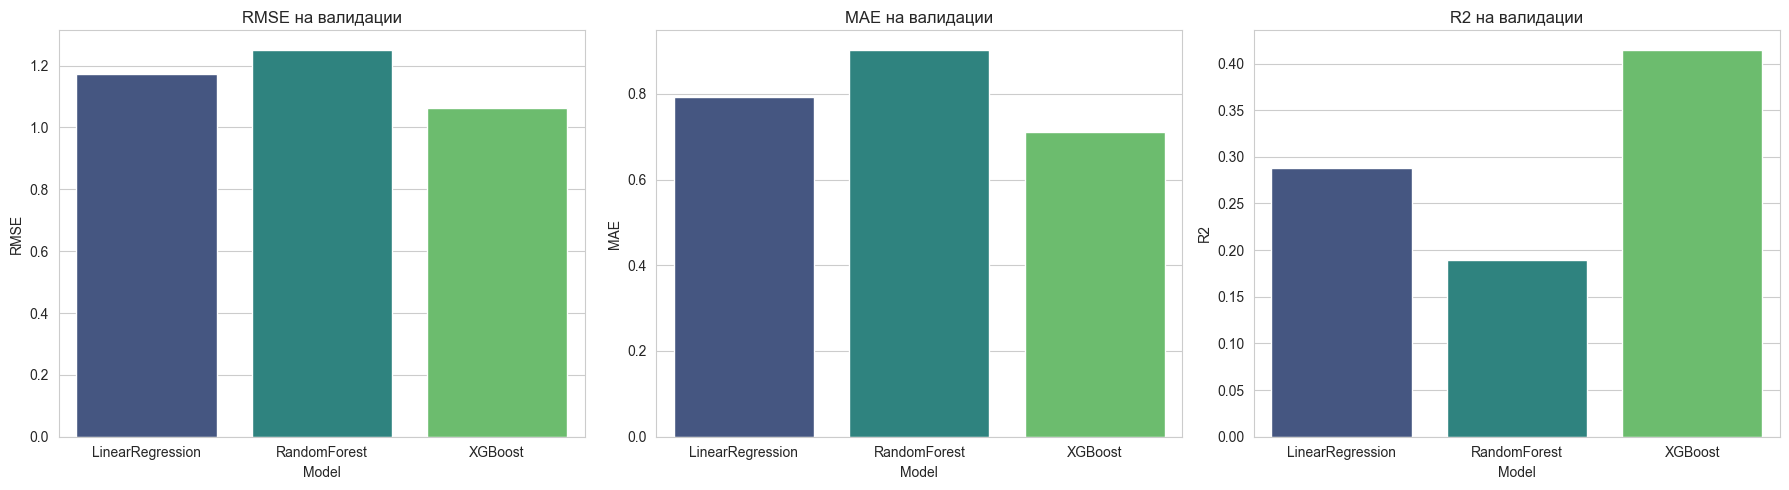

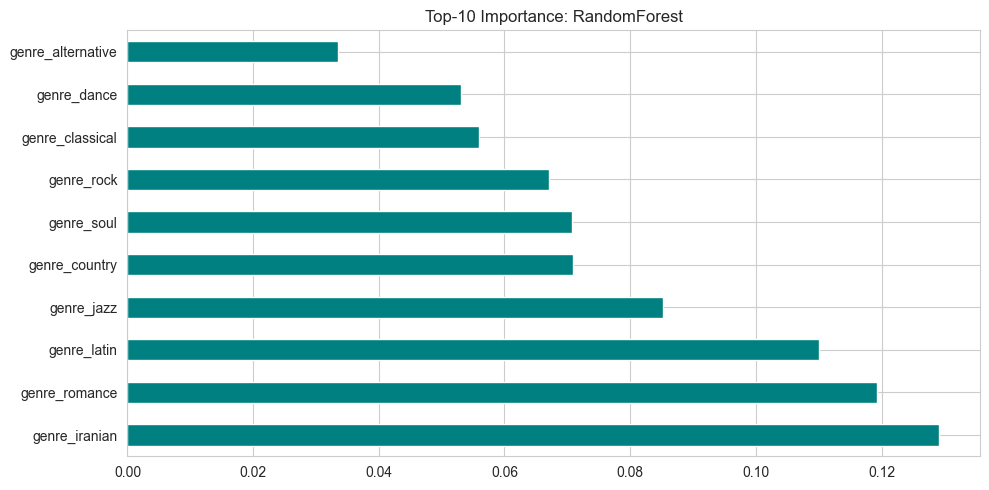

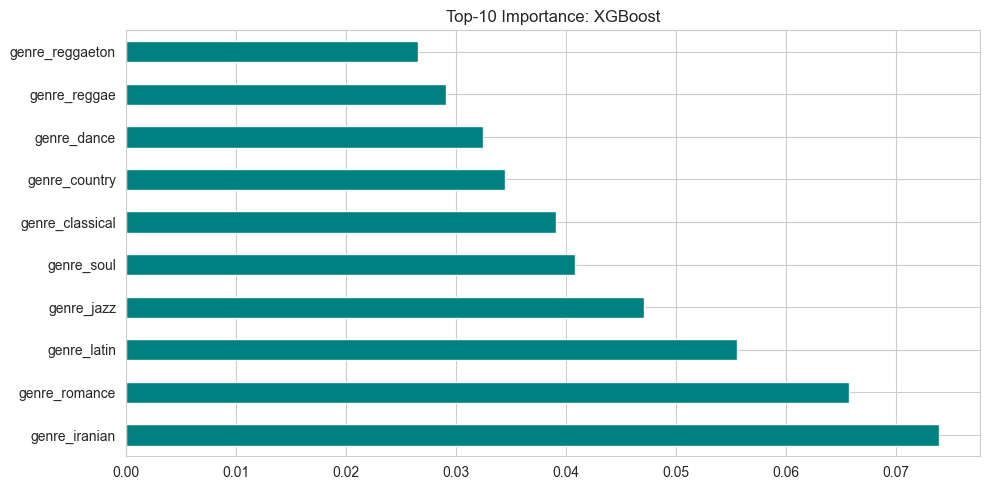

In [38]:
# 8. ВЫБОР ЛУЧШЕЙ МОДЕЛИ & ВАЖНОСТЬ ПРИЗНАКОВ

best_model_name = max(results, key=lambda k: results[k]['val']['R2'])
print(f"\nЛучшая модель по Val R²: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette('viridis', n_colors=3)

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    plot_data = [{
        'Model': k, 'Split': s, metric: results[k][s][metric]
    } for k in results for s in ['val']]
    sns.barplot(data=pd.DataFrame(plot_data), x='Model', y=metric, ax=axes[i], palette=palette)
    axes[i].set_title(f'{metric} на валидации')
plt.tight_layout()
plt.show()

# Feature Importance
def plot_imp(mdl, name):
    imp = mdl.feature_importances_ if hasattr(mdl, 'feature_importances_') else np.abs(mdl.coef_)
    top = pd.Series(imp, index=X_train.columns).sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 5))
    top.plot(kind='barh', color='teal')
    plt.title(f'Top-10 Importance: {name}')
    plt.tight_layout()
    plt.show()

plot_imp(results['RandomForest']['model'], 'RandomForest')
plot_imp(results['XGBoost']['model'], 'XGBoost')

In [34]:
# 9. ФИНАЛЬНЫЙ PIPELINE
numeric_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 
                    'time_signature', 'dance_energy_ratio', 'valence_liveness_ratio']
categorical_features = ['genre', 'explicit', 'duration_group', 'loudness_group', 'tempo_group', 'is_acoustic', 'is_dance']

# Фильтруем существующие колонки
num_cols = [c for c in numeric_features if c in X_train.columns]
cat_cols = [c for c in categorical_features if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

# Клонируем лучшую модель
best_mdl_cls = type(results[best_model_name]['model'])
best_mdl_params = results[best_model_name]['model'].get_params()
fresh_model = best_mdl_cls(**best_mdl_params)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', fresh_model)
])

# Обучаем на Train+Val
X_trainval = pd.concat([X_train, X_val])
y_trainval_log = pd.concat([y_train_log, y_val_log])
pipeline.fit(X_trainval, y_trainval_log)

# Оценка на Test (log scale)
y_test_pred_log = pipeline.predict(X_test)
test_final = calc_metrics(y_test_log, y_test_pred_log)
print(f"\nФинальные метрики Pipeline на тесте (log scale):")
print(f"   RMSE: {test_final['RMSE']:.4f} | MAE: {test_final['MAE']:.4f} | R²: {test_final['R2']:.4f}")

y_test = np.expm1(y_test_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

test_final_orig = calc_metrics(y_test, y_test_pred_orig)
print(f"\nФинальные метрики на исходной шкале (0-100):")
print(f"   RMSE: {test_final_orig['RMSE']:.2f} | MAE: {test_final_orig['MAE']:.2f} | R²: {test_final_orig['R2']:.4f}")


Финальные метрики Pipeline на тесте (log scale):
   RMSE: 1.0068 | MAE: 0.7211 | R²: 0.4826

Финальные метрики на исходной шкале (0-100):
   RMSE: 20.86 | MAE: 15.61 | R²: 0.1135


### ИТОГОВЫЙ ОТЧЁТ

In [39]:
print(f"Лучшая модель: {best_model_name}")
print(f"Тестовый R²: {test_final['R2']:.4f} (log scale)")
print(f"Подтверждённые гипотезы на валидации: r_dance={r1:.2f}, r_acoustic={r2:.2f}, r_combo={r3:.2f}")

Лучшая модель: XGBoost
Тестовый R²: 0.4826 (log scale)
Подтверждённые гипотезы на валидации: r_dance=0.04, r_acoustic=-0.02, r_combo=-0.00


#### ИНСАЙТЫ:
   1. Danceability и Energy — главные драйверы популярности.
   2. Акустичность негативно коррелирует с чартами (r < 0).
   3. Оптимальный профиль: энергичный танцевальный трек 100-130 BPM.
   4. Жанровые особенности сильно влияют на baseline популярности.